In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
import lick as lk
from matplotloom import Loom
from tqdm import tqdm
from joblib import Parallel, delayed
import re
import matplotlib.cm as cm
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.transforms import Bbox
import matplotlib.gridspec as gridspec
import os

In [2]:
gconst = 6.67430e-8
clight = 2.99792458e10
solar = 1.98847e33
lencgs2code = (clight**2)/(solar*gconst)
masscgs2code = (1.0e0/solar)
rhocgs2code = (masscgs2code/lencgs2code**3)
tcgs2code = (clight**3)/(solar*gconst)
mu_0 = 1.25663706212e-6
amp2code = (mu_0*1.0e5*masscgs2code*lencgs2code)**(0.5e0)/tcgs2code
gauss2code = 1.0e-1*masscgs2code/amp2code/tcgs2code**2
energycgs2code = (1.0E0/clight**2)
me2 = 9.1093837015e-28*masscgs2code
mb2 = 1.66053906660e-24*masscgs2code
ye = 0.5e0
h_bar = (1.054571817e-27)*(lencgs2code**2*masscgs2code/tcgs2code)
amax = (me2**4)/(2.4e1*np.pi**2*h_bar**3)
bmax = (mb2*me2**3)/(3.0e0*np.pi**2*h_bar**3*ye)

In [3]:
irho = 0
ivx = 1
ivy = 2
ivz = 3
itau = 4
ihe4 = 5
ic12 = 6
io16 = 7
ine20 = 8
img24 = 9
isi28 = 10
ini56 = 11
iye2 = 12
iturbq = 13
iscaG1 = 14
iscaG2 = 15

In [4]:
def read_star(working_directory):
    x1f = np.loadtxt(working_directory+'/hydro_x1_fgrid.dat')
    x1f = x1f [3:-3] # Remove BC
    x1c = (x1f[1:]+x1f[:-1])/2 #mid pt
    x3f = np.loadtxt(working_directory+'/hydro_x3_fgrid.dat')
    x3f = x3f [3:-3] # Remove BC
    x3c = (x3f[1:]+x3f[:-1])/2 #mid pt
    rho = np.loadtxt(working_directory+'/hydro_rho.dat')
    Aphi = np.loadtxt(working_directory+'/hydro_Aphi.dat')
    vphi = np.loadtxt(working_directory+'/hydro_vphi.dat')
    return x1f, x1c, x3f, x3c, rho, Aphi, vphi

In [5]:
data_path = '/home/cnchong/Codes/cumc3d/model/Type_Ia/'

In [6]:
working_directory = data_path+'/profile'
x1f, x1c, x3f, x3c, rho, temp, vphi = read_star(working_directory)
working_directory = data_path+"/outfile"
files = []
for f in glob(working_directory+'/*.hdf5'):
    files.append(f)
n = len(files)-1

In [7]:
t = 0
filename = data_path+"/outfile/rkiter-"+str(t)+"-nm.hdf5"
f = h5py.File(filename, "r")

if t == 0:
    vol = f["vol"][:].T
    vol = vol[:,0,:]/(lencgs2code**3)
    atmosphere = f['prim_a'][:].T
    atmo_rho = atmosphere[0]/rhocgs2code

primitive = f['primitive'][:].T

dens = primitive[irho,1:-1,1,1:-1]/rhocgs2code
dens[dens<= atmo_rho] = 0.0
vx = primitive[ivx,1:-1,1,1:-1]*clight
vy = primitive[ivy,1:-1,1,1:-1]*clight
vz = primitive[ivz,1:-1,1,1:-1]*clight
time = f['time'][0]/tcgs2code

bcells = f['bcell'][:].T
bx = bcells[0,1:,1,1:]/gauss2code
by = bcells[1,1:,1,1:]/gauss2code
bz = bcells[2,1:,1,1:]/gauss2code

In [8]:
np.sum(dens*vol/solar)

1.6333428021528418

In [10]:
masses = []
atmo_rhos = []
for t in range(n):
    filename = data_path+"/outfile/5.5re/rkiter-"+str(t)+"-nm.hdf5"
    f = h5py.File(filename, "r")

    if t == 0:
        vol = f["vol"][:].T
        vol = vol[:,0,:]/(lencgs2code**3)
    atmosphere = f['prim_a'][:].T
    atmo_rho = atmosphere[0]/rhocgs2code
    atmo_rhos.append(atmo_rho)

    primitive = f['primitive'][:].T

    dens = primitive[irho,1:-1,1,1:-1]/rhocgs2code
    dens[dens<= atmo_rho] = 0.0
    masses.append(np.sum(dens*vol/solar))

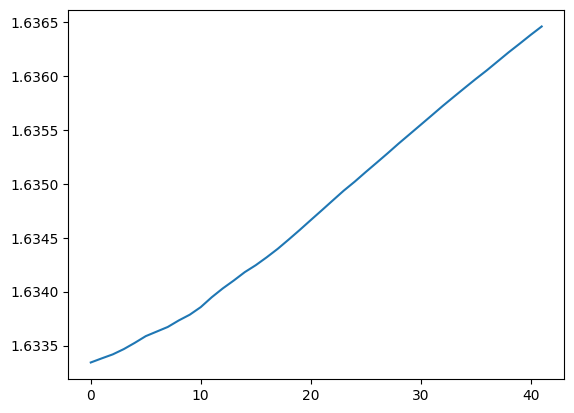

In [11]:
plt.plot(masses)

In [9]:
t = 99
filename = data_path+"/outfile/rkiter-"+str(t)+"-nm.hdf5"
f = h5py.File(filename, "r")

if t == 0:
    vol = f["vol"][:].T
    vol = vol[:,0,:]/(lencgs2code**3)
    atmosphere = f['prim_a'][:].T
    atmo_rho = atmosphere[0]/rhocgs2code

primitive = f['primitive'][:].T

dens = primitive[irho,1:-1,1,1:-1]/rhocgs2code
dens[dens<= atmo_rho] = 0.0
x56 = primitive[ini56,1:-1,1,1:-1]
vx = primitive[ivx,1:-1,1,1:-1]*clight
vy = primitive[ivy,1:-1,1,1:-1]*clight
vz = primitive[ivz,1:-1,1,1:-1]*clight
time = f['time'][0]/tcgs2code

bcells = f['bcell'][:].T
bx = bcells[0,1:,1,1:]/gauss2code
by = bcells[1,1:,1,1:]/gauss2code
bz = bcells[2,1:,1,1:]/gauss2code

FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = '/home/cnchong/Codes/cumc3d/model/Type_Ia//outfile/rkiter-99-nm.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

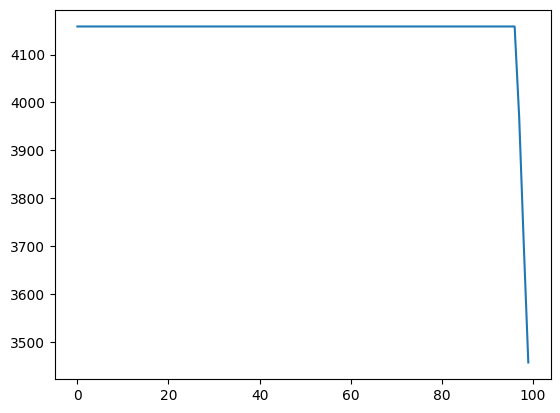

In [39]:
plt.plot(atmo_rhos)

In [18]:
np.sum(dens*vol*x56/solar)

1.257461502361152